## Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.stats.proportion import proportions_ztest


In [142]:
df_ga = pd.read_csv(
    "../data/processed/sessions_clean.csv",
    dtype={"fullVisitorId": str}
)

In [143]:

df_weather = pd.read_csv("../data/processed/weather_countries_clean.csv")
df_internet = pd.read_csv("../data/processed/internet_clean.csv")
df_fixed_broadband = pd.read_csv("../data/processed/fixed_broadband_clean.csv")
df_gdp = pd.read_csv("../data/processed/gdp_clean.csv")
df_mobile_broadband = pd.read_csv("../data/processed/mobile_broadband_clean.csv")


## Data Merging

In [ ]:
df_ga['date'] = pd.to_datetime(df_ga['date'])
df_weather['date'] = pd.to_datetime(df_weather['date'])

In [ ]:
df_ga['country'] = df_ga['country'].str.strip()
df_weather['country'] = df_weather['country'].str.strip()

In [ ]:
df = df_ga.copy()

# GA + Weather
df = df.merge(df_weather, on=['date', 'country'], how='left')

# + Internet
df = df.merge(df_internet, on='country', how='left')

# + Broadband
df = df.merge(df_fixed_broadband, on='country', how='left')

# + GDP
df = df.merge(df_gdp, on='country', how='left')

df = df.merge(df_mobile_broadband, on='country', how='left')


In [144]:
countries = ["United States", "Germany", "United Kingdom", "Japan", "Brazil", "Turkey", "Thailand", "Viet Nam","Vietnam", "Canada",  "India"]

df = df[df['country'].isin(countries)]

df['country'] = df['country'].replace({
    'Viet Nam': 'Vietnam'
})

In [146]:
df["country"].unique()

<StringArray>
[ 'United States',         'Turkey',       'Thailand',        'Vietnam',
          'India',        'Germany', 'United Kingdom',         'Brazil',
         'Canada',          'Japan']
Length: 10, dtype: str

## Introduction

### Objective

Analyze how weather conditions (temperature, precipitation) impact user conversion rates across countries, controlling for economic and infrastructure factors.

### Key Questions

- What is the causal impact of precipitation on conversion rate?
- How does temperature influence conversion across different ranges?
- Are there interaction effects between weather and country-level factors?

### Hypotheses

- Conversion rate decreases on days with precipitation
- Conversion follows a non-linear relationship with temperature (optimal range hypothesis)

## Data Overview & Validation

Before starting the analysis, we validate the dataset to ensure:
- Correct data types
- No duplication issues after merges
- Consistent session-level granularity
- Minimal missing data

In [147]:
df.head()

,user_id,session_id,date,country,device,channel,day_of_week,month,is_returning,pageview_bucket,...,wind_category,is_snowing,is_weekend,month_num,season,pages_per_visit,engagement_level,returning_converter,channel_type,converted_pct
0,5103959234087,1471817208,2016-08-21,United States,mobile,Organic Search,Sunday,2016-08,True,"(5, 10]",...,moderate,False,True,8,summer,8.0,High,False,Organic,0
1,85059828173212,1500505105,2017-07-19,United States,mobile,Direct,Wednesday,2017-07,True,"(0, 1]",...,moderate,False,False,7,summer,1.0,Low,False,Organic,0
3,33471059618621,1480289088,2016-11-27,Turkey,desktop,Social,Sunday,2016-11,True,"(0, 1]",...,low,False,True,11,fall,1.0,Low,False,Organic,0
4,388388833742701,1480256233,2016-11-27,Thailand,desktop,Social,Sunday,2016-11,True,"(1, 5]",...,moderate,False,True,11,fall,2.0,Medium,False,Organic,0
5,426241577666985,1479449976,2016-11-17,Turkey,desktop,Social,Thursday,2016-11,True,"(1, 5]",...,low,False,False,11,fall,2.0,Medium,False,Organic,0


In [148]:
df.columns

Index(['user_id', 'session_id', 'date', 'country', 'device', 'channel',
       'day_of_week', 'month', 'is_returning', 'pageview_bucket', 'revenue',
       'transactions', 'visits', 'pageviews', 'converted', 'temp_mean',
       'temp_max', 'temp_min', 'wind_speed', 'precipitation', 'rain', 'snow',
       'precip_hours', 'wind_gusts', 'sunshine_hours', 'daylight_hours',
       'avg_internet_usage_pct',
       'fixed_broadband_subscriptions_per_100_people', 'gdp_per_capita',
       'country_code', 'mobile_broadband_subscriptions_per_100_people',
       'region', 'gdp_category', 'internet_category', 'rain_category',
       'temp_category', 'extreme_weather', 'pleasant_weather',
       'weather_condition', 'sunshine_category', 'wind_category', 'is_snowing',
       'is_weekend', 'month_num', 'season', 'pages_per_visit',
       'engagement_level', 'returning_converter', 'channel_type',
       'converted_pct'],
      dtype='str')

In [149]:
df = df.rename(columns={
    'fullVisitorId': 'user_id',
    'visitId': 'session_id',
    'channelGrouping': 'channel'
})

In [150]:
df = df.drop(columns = ["country_code_y", 'country_code_x'], errors = 'ignore')

In [152]:
df.shape

(603300, 50)

In [153]:
df.info()

<class 'pandas.DataFrame'>
Index: 603300 entries, 0 to 901286
Data columns (total 50 columns):
 #   Column                                         Non-Null Count   Dtype         
---  ------                                         --------------   -----         
 0   user_id                                        603300 non-null  str           
 1   session_id                                     603300 non-null  str           
 2   date                                           603300 non-null  datetime64[us]
 3   country                                        603300 non-null  str           
 4   device                                         603300 non-null  str           
 5   channel                                        603300 non-null  str           
 6   day_of_week                                    603300 non-null  str           
 7   month                                          603300 non-null  str           
 8   is_returning                                   603300 non-nu

Fix data granularity:
- Original data had multiple rows per session (fullVisitorId + visitId), which duplicated revenue after merges.

- This aggregation ensures 1 row per session and correct metrics.

- fullVisitorId identifies a user, visitId identifies a session. Together they define a unique session.

In [ ]:
print(df[df['revenue'].notnull()].duplicated(
    subset=['user_id', 'session_id']
).sum())

print(df.groupby(['user_id', 'session_id']).size().max())

0
1


We confirm that each session is uniquely defined by (user_id, session_id), ensuring no duplication after merging external datasets.

In [161]:
print((df['revenue'] == 0).sum())

592090


In [156]:
df.isnull().sum()

user_id                                              0
session_id                                           0
date                                                 0
country                                              0
device                                               0
channel                                              0
day_of_week                                          0
month                                                0
is_returning                                         0
pageview_bucket                                     63
revenue                                              0
transactions                                         0
visits                                               0
pageviews                                            0
converted                                            0
temp_mean                                            0
temp_max                                             0
temp_min                                             0
wind_speed

In [157]:
df.dtypes

user_id                                                     str
session_id                                                  str
date                                             datetime64[us]
country                                                     str
device                                                      str
channel                                                     str
day_of_week                                                 str
month                                                       str
is_returning                                               bool
pageview_bucket                                             str
revenue                                                 float64
transactions                                            float64
visits                                                    int64
pageviews                                                 int64
converted                                                 int64
temp_mean                               

In [158]:
df['user_id'] = df['user_id'].astype(str)
df['session_id'] = df['session_id'].astype(str)

In [159]:
df.dtypes

user_id                                                     str
session_id                                                  str
date                                             datetime64[us]
country                                                     str
device                                                      str
channel                                                     str
day_of_week                                                 str
month                                                       str
is_returning                                               bool
pageview_bucket                                             str
revenue                                                 float64
transactions                                            float64
visits                                                    int64
pageviews                                                 int64
converted                                                 int64
temp_mean                               

In [160]:
df.select_dtypes(include='number').describe()

,revenue,transactions,visits,pageviews,converted,temp_mean,temp_max,temp_min,wind_speed,precipitation,...,wind_gusts,sunshine_hours,daylight_hours,avg_internet_usage_pct,fixed_broadband_subscriptions_per_100_people,gdp_per_capita,mobile_broadband_subscriptions_per_100_people,month_num,pages_per_visit,converted_pct
count,603300.000000,603300.000000,603300.0,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,...,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000,603300.000000
mean,2.835953,0.019407,1.0,4.412327,0.018581,16.440531,21.556649,12.298357,17.498467,2.839818,...,39.583022,9.313276,12.123709,77.273538,27.700802,43729.924227,103.677038,7.009751,4.412327,1.858114
std,100.450601,0.150279,0.0,7.654308,0.135040,10.683060,11.032873,10.477388,6.628235,7.155439,...,14.039741,3.641182,1.968059,21.091585,11.082641,21780.860354,35.069701,3.491468,7.654308,13.504040
min,0.000000,0.000000,1.0,0.000000,0.000000,-32.500000,-28.500000,-38.600000,4.400000,0.000000,...,11.900000,0.000000,6.900000,17.350000,1.350000,1828.806806,20.770000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,1.0,1.000000,0.000000,8.800000,13.800000,4.400000,12.400000,0.000000,...,29.500000,7.900000,10.700000,84.280000,31.600000,39104.763048,83.910000,4.000000,1.000000,0.000000
50%,0.000000,0.000000,1.0,2.000000,0.000000,18.700000,24.000000,14.100000,16.700000,0.000000,...,37.400000,10.100000,12.000000,86.410000,32.340000,58636.600138,127.090000,7.000000,2.000000,0.000000
75%,0.000000,0.000000,1.0,4.000000,0.000000,25.100000,30.200000,21.100000,21.700000,1.400000,...,47.500000,11.800000,13.600000,86.410000,32.340000,58636.600138,127.090000,10.000000,4.000000,0.000000
max,47082.060000,25.000000,1.0,466.000000,1.000000,38.800000,45.100000,33.000000,43.500000,71.300000,...,105.800000,17.000000,17.700000,92.600000,39.240000,58636.600138,133.150000,12.000000,466.000000,100.000000


- Conversion rate is ~1.8%, which is realistic for e-commerce
- Pageviews show high variance, indicating different engagement levels
- Temperature ranges from -32°C to 38°C, allowing analysis across extreme conditions

### Key Findings

- The dataset contains **603k sessions and 50 features**
- No duplication at session level (`user_id + session_id` is unique)
- Revenue distribution is highly skewed:
  - ~98% of sessions have zero revenue (expected in e-commerce)
- Missing values are negligible (only `pageview_bucket` has minor gaps)
- Data types are consistent and ready for analysis

# Feature Engineering

To better understand conversion behavior, we create contextual features that capture:

- **User intent** (engagement, returning users, channel type)
- **Environmental conditions** (weather, temperature, precipitation)
- **Macro-economic context** (GDP, internet adoption)
- **Temporal patterns** (seasonality, weekends)

These features are designed to uncover non-linear effects and interaction patterns that are not visible in raw data.

Feature engineering is performed to enrich the dataset with contextual variables (macro, weather, and time), enabling deeper analysis of factors influencing user behavior and conversion.

## Region Context

Countries are grouped into World Bank regions to capture structural differences in economic development and digital maturity, which may influence conversion behavior.

In [ ]:

region_map = {
    "Germany": "Europe & Central Asia",
    "United Kingdom": "Europe & Central Asia",
    "Turkey": "Europe & Central Asia",

    "Japan": "East Asia & Pacific",
    "Thailand": "East Asia & Pacific",
    "Vietnam": "East Asia & Pacific",

    "India": "South Asia",

    "United States": "North America",
    "Canada": "North America",

    "Brazil": "Latin America & Caribbean"
}


df["region"] = df["country"].map(region_map)

## Macro Context

### GDP per Capita Categories

GDP per capita is used as a proxy for purchasing power.

Segmenting countries into income groups allows us to analyze whether:
- Users in high-income countries convert more frequently
- Economic context moderates the impact of weather on behavior

In [ ]:

def gdp_category(x):
    if x <= 1135:
        return "Low income"
    elif x <= 4465:
        return "Lower-middle income"
    elif x <= 13845:
        return "Upper-middle income"
    else:
        return "High income"

df["gdp_category"] = df["gdp_per_capita"].apply(gdp_category)

### Internet Usage Categories

Internet category represents the level of digital adoption in a country, based on the percentage of the population using the internet.

Internet penetration reflects digital maturity.

Higher adoption levels may correlate with:
- Greater user familiarity with online shopping
- Higher baseline conversion rates

In [ ]:
df['internet_category'] = pd.qcut(
    df['avg_internet_usage_pct'].rank(method='first'),
    q=3,
    labels=['Low Internet', 'Medium Internet', 'High Internet']
)


Internet usage is categorized using quantiles.

Ranking is applied to avoid duplicate bin edges caused by repeated country-level values.

## Weather Context

Weather features are categorized to capture non-linear effects as environmental variables often do not have a simple linear relationship with user behavior.

Weather variables are discretized to capture non-linear behavioral effects.

For example:
- Light rain may not affect behavior
- Heavy rain may discourage browsing or purchases
- Moderate temperatures may increase user comfort and engagement

Binary flags such as `extreme_weather` and `pleasant_weather` simplify interpretation 
and enable clearer comparisons.

### Rain Categories


In [162]:
def classify_precipitation(x):
    if x == 0:
        return "no rain"
    elif x <= 2:
        return "light rain"
    elif x <= 10:
        return "moderate rain"
    elif x <= 30:
        return "heavy rain"
    else:
        return "extreme rain"

df['rain_category'] = df['precipitation'].apply(classify_precipitation)

### Temperature Categories

In [163]:
def classify_temperature(x):
    if x < 5:
        return "very cold"
    elif x < 15:
        return "cold"
    elif x < 25:
        return "mild"
    elif x < 30:
        return "warm"
    else:
        return "hot"

df['temp_category'] = df['temp_mean'].apply(classify_temperature)

### Extreme Weather Category

In [164]:
df['extreme_weather'] = (
    (df['precipitation'] > 30) |
    (df['temp_mean'] < 0) |
    (df['temp_mean'] > 30) |
    (df['wind_speed'] > 30)
)

In [165]:
df['extreme_weather'].value_counts(normalize=True)*100

extreme_weather
False    82.926902
True     17.073098
Name: proportion, dtype: float64

### Pleasant Weather Category

In [166]:
df['pleasant_weather'] = (
    df['temp_category'].isin(['mild', 'warm']) &
    df['rain_category'].isin(['no rain', 'light rain']) &
    (df['extreme_weather'] == False)
)

A composite feature (`pleasant_weather`) is created to represent favorable conditions 
(mild/warm temperatures with little or no rain).

This allows testing whether optimal environmental conditions increase conversion likelihood.

### Weather Condition Category

In [167]:
def weather_condition(row):
    if row['extreme_weather']:
        return 'Extreme'
    elif (
        row['temp_category'] in ['mild', 'warm'] and
        row['rain_category'] in ['no rain', 'light rain']
    ):
        return 'Pleasant'
    else:
        return 'Neutral'

df['weather_condition'] = df.apply(weather_condition, axis=1)

### Sunshine Categories

In [168]:
df['sunshine_category'] = pd.cut(
    df['sunshine_hours'],
    bins=[0, 4, 8, 12, 24],
    labels=['low', 'medium', 'high', 'very high']
)

### Wind Categories

In [169]:
df['wind_category'] = pd.cut(
    df['wind_speed'],
    bins=[0, 10, 20, 40, 100],
    labels=['low', 'moderate', 'high', 'extreme']
)

### Snow Category

In [ ]:

df['is_snowing'] = df['snow'] > 0


Snow is infrequent and unevenly distributed, which can lead to small sample sizes.

Therefore, it is modeled as a binary variable (presence vs absence) instead of categories.

## Time Context

In [ ]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
# Identifies weekend sessions.
# User behavior often differs on weekends due to more free time and different browsing patterns.

In [ ]:
df['month_num'] = df['date'].dt.month
# Extracts the month from the date.
# Useful for time-based analysis and potential seasonality patterns.

In [ ]:

df['season'] = df['month_num'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall', 10: 'fall', 11: 'fall'
})


Season is approximated using the Northern Hemisphere calendar.

This introduces some noise for countries in other hemispheres (e.g., Brazil),
but is acceptable as a high-level temporal proxy.

## User Behavior Features

User-level features capture behavioral intent:

- Engagement (pages per visit) reflects browsing depth
- Returning converters indicate user loyalty
- Channel type differentiates acquisition intent (paid vs organic)

These variables are key drivers of conversion and will be used as control variables.

In [ ]:
df['pages_per_visit'] = df['pageviews'] / df['visits']

Measures user engagement per session.

Higher values indicate deeper interaction with the website, which may increase conversion likelihood.

In [ ]:
def engagement(x):
    if x < 2: return 'Low'
    elif x < 5: return 'Medium'
    else: return 'High'

df['engagement_level'] = df['pages_per_visit'].apply(engagement)
# Categorizes user engagement into levels for easier interpretation.
# Helps identify how engagement intensity relates to conversion behavior.

Categorizes user engagement into levels for easier interpretation.

Helps identify how engagement intensity relates to conversion behavior.

In [ ]:
df['returning_converter'] = df['is_returning'] & df['converted']

Identifies loyal users who return and convert.

Useful to understand the impact of user retention on conversion performance.

In [ ]:
def classify_channel(x):
    if x in ['Paid Search', 'Display']:
        return 'Paid'
    elif x in ['Organic Search', 'Direct', 'Referral', 'Social']:
        return 'Organic'
    else:
        return 'Other'

df['channel_type'] = df['channel'].apply(classify_channel)



Groups traffic sources into Paid vs Organic channels.

Important to distinguish user intent: paid users are driven by ads, while organic users show higher intent.

Enables analysis of how acquisition source influences engagement and conversion.

### Target Variable

Conversion is analyzed using:
- Binary indicator (`converted`)
- Conversion rate (`converted_pct`)

This allows both classification and rate-based analysis.

## Analysis (Session Level)

We analyze how weather conditions impact user conversion behavior at the session level.

All metrics are computed as:
- Conversion rate = mean(converted)
- Aggregated across sessions to reflect real user behavior

We focus on:
- Individual effects (rain, temperature)
- Interaction effects (rain + temperature)
- Behavioral efficiency (conversion vs engagement)

### Impact of Rain on Conversion



**Hypothesis:** Rain reduces conversion rates.


In [171]:
df_rain = (df.groupby('rain_category')['converted'].mean() * 100).round(2)
df_rain.rename("conversion_rate_%")

rain_category
extreme rain     3.18
heavy rain       1.99
light rain       1.66
moderate rain    1.22
no rain          2.03
Name: conversion_rate_%, dtype: float64

In [172]:
df.groupby('rain_category').size()

rain_category
extreme rain      10438
heavy rain        49488
light rain       148790
moderate rain     70929
no rain          323655
dtype: int64

 Interpretation

Rain shows a **non-linear effect** on conversion:

- Light and moderate rain are associated with **lower conversion rates**
- Heavy rain shows recovery to baseline levels
- Extreme rain shows higher conversion, but this segment represents a **small portion of the data (~1.7%)**

Overall, results suggest that:
- Mild adverse weather reduces conversion
- Extreme conditions may reflect **specific behavioral contexts** rather than a general trend

Therefore, the relationship between rain and conversion is **non-linear and context-dependent**.

In [175]:
df['rain_simple'] = df['rain_category'].map({
    'no rain': 'No rain',
    'light rain': 'Rain',
    'moderate rain': 'Rain',
    'heavy rain': 'Rain',
    'extreme rain': 'Rain'
})

In [174]:
df.groupby('rain_simple')['converted'].mean()

rain_simple
no rain    0.020259
rain       0.016639
Name: converted, dtype: float64

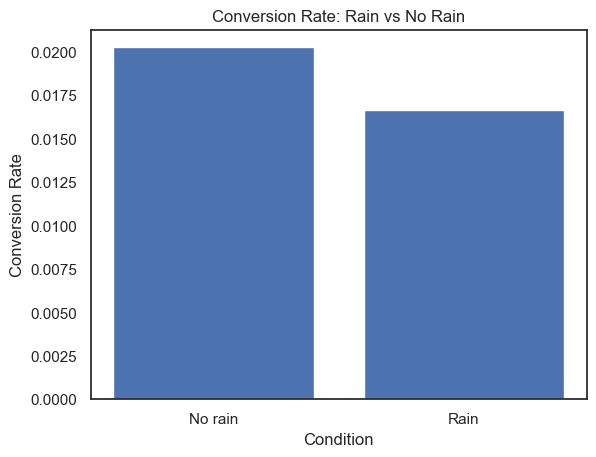

In [ ]:
# Aggregation
df_plot = df.groupby('rain_simple')['converted'].mean().reset_index()

# Plot
plt.figure()
plt.bar(df_plot['rain_simple'], df_plot['converted'])

plt.title('Conversion Rate: Rain vs No Rain')
plt.xlabel('Condition')
plt.ylabel('Conversion Rate')

plt.show()

Visualization

Conversion rates are higher in non-rainy conditions.

Rain is associated with a noticeable drop in conversion performance.

In [ ]:
# Split groups
rain = df[df['rain_simple'] == 'Rain']
no_rain = df[df['rain_simple'] == 'No rain']

# Successes (conversions)
count = [
    rain['converted'].sum(),
    no_rain['converted'].sum()
]

# Total observations
nobs = [
    len(rain),
    len(no_rain)
]

# Z-test
stat, pval = proportions_ztest(count, nobs)

print("Z-stat:", stat)
print("p-value:", pval)

Z-stat: -10.383794548709652
p-value: 2.9385796184771414e-25


Statistical Test

A two-proportion z-test was conducted to compare conversion rates between rainy and non-rainy sessions.

**Result:**
- The difference is statistically significant (p < 0.001)
- Z-statistic: -10.38

**Interpretation:**
Conversion rates are significantly lower during rainy conditions.  
The negative z-statistic indicates that rain has a measurable negative effect on user conversion behavior.

**Effect Size:**
- No rain: ~2.03%
- Rain: ~1.66%
- Relative decrease: ~18%

While the result is statistically significant, the magnitude of the effect is moderate.  
This suggests that rain influences user behavior, but is not the primary driver of conversion.

### Impact of Temperature on Conversion


In [179]:
df_temp = (df.groupby('temp_category')['converted'].mean() * 100).round(2)
df_temp.rename("conversion_rate_%")

temp_category
cold         1.92
hot          1.15
mild         1.98
very cold    1.74
warm         1.85
Name: conversion_rate_%, dtype: float64

In [180]:
df.groupby('temp_category').size()

temp_category
cold         152695
hot           29146
mild         197790
very cold     97828
warm         125841
dtype: int64

Conversion rates remain relatively stable across most temperature categories, 
generally ranging between ~1.7% and ~2.0%.

However, hot conditions show a clear drop in conversion (~1.15%), 
representing a substantial decrease compared to milder temperatures (~40% lower than peak levels).

Given the sufficient sample size (~29k sessions), this suggests that high temperatures 
have a meaningful negative impact on conversion behavior.

Overall, temperature alone is not a strong driver of conversion, 
but extreme heat appears to significantly reduce user propensity to convert.

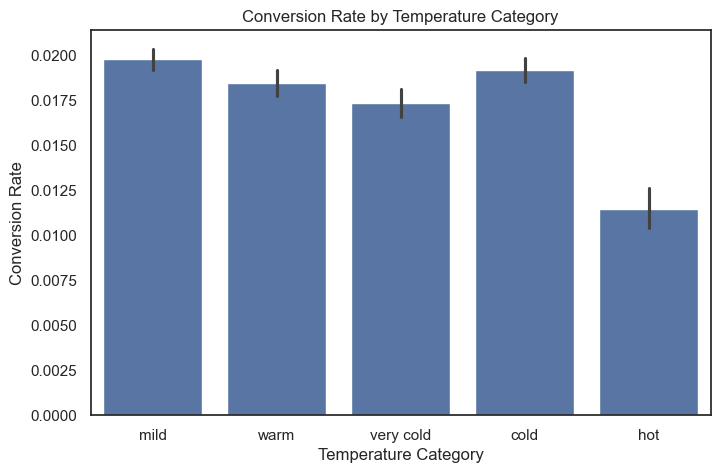

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='temp_category',
    y='converted',
    estimator='mean',
    errorbar=('ci', 95)
)

plt.title('Conversion Rate by Temperature Category')
plt.ylabel('Conversion Rate')
plt.xlabel('Temperature Category')

plt.show()

In [182]:
import statsmodels.formula.api as smf

model = smf.logit("converted ~ C(temp_category)", data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.092364
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               603300
Model:                          Logit   Df Residuals:                   603295
Method:                           MLE   Df Model:                            4
Date:                Tue, 05 May 2026   Pseudo R-squ.:                0.001084
Time:                        16:26:34   Log-Likelihood:                -55723.
converged:                       True   LL-Null:                       -55784.
Covariance Type:            nonrobust   LLR p-value:                 3.441e-25
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.9344      0.019   -210.879      0.

A logistic regression model was used to assess the impact of temperature on conversion probability.

Results indicate that:

- High temperatures ("hot") have a statistically significant negative effect on conversion (p < 0.001)
- Very cold conditions also show a smaller but significant negative impact (p < 0.01)
- Other temperature categories (mild, warm) are not statistically different from the baseline

Despite statistical significance, the model explains very little of the overall variation in conversion behavior (Pseudo R² ≈ 0.001).

This suggests that temperature alone is not a strong driver of conversion, 
though extreme conditions — particularly heat — can negatively influence user behavior.

Cold temperatures are used as the baseline category in the regression model.  
Results show that:

- Conversion rates are significantly lower in hot and very cold conditions compared to cold  
- No significant differences are observed between cold, mild, and warm temperatures  

This suggests that moderate temperature ranges behave similarly, while extreme conditions drive changes in user behavior.

### Combined Effect of Weather Conditions

In [ ]:
counts = df.groupby(['rain_category', 'temp_category']).size().reset_index(name='count')
conversion = df.groupby(['rain_category', 'temp_category'])['converted'].mean().reset_index()
df_analysis = conversion.merge(counts)
df_analysis['low_sample'] = df_analysis['count'] < 1000
df_analysis['converted'] = df_analysis['converted'] * 100
print(df_analysis)

Some category combinations (e.g., extreme rain with very cold temperatures) have relatively low sample sizes, which may affect the reliability of these specific results.

Conversion rates are highest under warm and dry conditions, and this pattern is consistent across large sample sizes.

In [ ]:
# count
counts = df.groupby(['rain_category', 'temp_category']).size().reset_index(name='count')

# pageviews + conversion
metrics = df.groupby(['rain_category', 'temp_category'])[['pageviews', 'converted']].mean().reset_index()

# merge
df_analysis = metrics.merge(counts)

# low sample flag
df_analysis['low_sample'] = df_analysis['count'] < 1000

# converter conversion pra %
df_analysis['converted'] = df_analysis['converted'] * 100

# arredondar (opcional)
df_analysis[['pageviews', 'converted']] = df_analysis[['pageviews', 'converted']].round(2)

print(df_analysis)

Weather conditions affect different stages of the user journey differently, influencing browsing behavior and purchase decisions in distinct ways.

In [ ]:
df_analysis['engagement_efficiency'] = (df_analysis['converted']/100) / df_analysis['pageviews']
print(df_analysis)

In [ ]:
df_analysis.sort_values('engagement_efficiency', ascending=True)

Adverse weather conditions can increase conversion efficiency, especially during cold and rainy scenarios.

High user engagement does not necessarily translate into higher conversion efficiency, indicating different behavioral patterns across weather conditions.

Stable weather leads to more consistent and predictable user behavior, while extreme conditions create variability in both engagement and conversion.

## Additional Weather Factors

These additional variables reinforce that weather influences user behavior beyond temperature and precipitation, affecting both engagement and conversion patterns.

### User Behavior Under Extreme Weather Conditions

Does extreme weather conditions affect conversion rate?

When aggregated into a single variable, extreme weather conditions do not show a significant impact on conversion rates, suggesting that weather effects are more nuanced and context-dependent.

In [ ]:
df.groupby('extreme_weather')['converted'].mean() * 100

In [ ]:
df.groupby('extreme_weather')[['pageviews', 'converted']].mean()

Users tend to browse more during extreme weather conditions, but this does not translate into higher conversion rates.

#### Interaction Between Extreme Weather and Temperature

While extreme weather alone does not significantly impact conversion, its interaction with temperature reveals important patterns.

Extreme cold conditions are associated with higher conversion rates, while extreme heat significantly reduces conversion. This suggests that user behavior is highly context-dependent and influenced by specific environmental conditions.

In [ ]:
df.groupby(['extreme_weather', 'temp_category'])['converted'].mean() * 100

#### Interaction Between Extreme Weather and Rain

In [ ]:
df.groupby(['rain_category', 'extreme_weather'])['converted'].mean() *100

In [ ]:
count_rain = df.groupby(['rain_category', 'extreme_weather']).size().reset_index(name='count')
print(count_rain)

Extreme weather conditions tend to reduce conversion rates across most precipitation levels, reinforcing the idea that adverse conditions negatively impact purchasing behavior.

While extreme weather categories provide useful insights, they should be interpreted with caution as they aggregate diverse conditions. More granular analysis (e.g., temperature and precipitation categories) provides more reliable and interpretable results.

## Advanced Analysis

In [ ]:
df.select_dtypes(include='number').columns

In [ ]:
cols = [
    'revenue', 'transactions', 'visits', 'pageviews', 'temp_mean',
       'temp_max', 'temp_min', 'wind_speed', 'precipitation', 'rain', 'snow',
       'precip_hours', 'wind_gusts', 'sunshine_hours', 'daylight_hours',
       'avg_internet_usage_pct',
       'fixed_broadband_subscriptions_per_100_people', 'gdp_per_capita',
       'mobile_broadband_subscriptions_per_100_people', 'month_num',
       'pages_per_visit'
]

corr = df[cols].corr()

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation analysis reveals strong clustering among weather variables and socioeconomic indicators, suggesting redundancy within these groups. Business metrics such as revenue and transactions show expected positive relationships, while weather variables exhibit minimal influence on user behavior. Additionally, GDP and broadband penetration are highly correlated, indicating that economic development plays a key role in digital engagement.

# Clustering

## Cluster with US

We cluster countries based on macroeconomic and digital infrastructure indicators to identify different types of markets.

Countries were grouped based on digital maturity using clustering techniques.

This allows us to analyze user behavior not just by country, but by market type.

In [ ]:
df_country_cluster = df.groupby('country').agg({
    'gdp_per_capita': 'mean',
    'avg_internet_usage_pct': 'mean',
    'fixed_broadband_subscriptions_per_100_people': 'mean',
    'mobile_broadband_subscriptions_per_100_people': 'mean'
}).reset_index()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = df_country_cluster.drop(columns=['country'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_country_cluster['cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
df_country_cluster.groupby('cluster').mean(numeric_only=True)

In [ ]:
cluster_map = {
    0: 'Emerging Digital Markets',
    1: 'Developed Markets',
    2: 'Low Access Markets'
}

df_country_cluster['cluster_label'] = df_country_cluster['cluster'].map(cluster_map)

In [ ]:
df_country_cluster[['country', 'cluster_label']].sort_values('cluster_label')

In [ ]:
#df = df.merge(
    #df_country_cluster[['country', 'cluster_label']],
    #on='country',
    #how='left'
#)

In [ ]:
#df_country_cluster_behavior = df.groupby(['country', 'cluster_label']).agg({
    #'converted': 'mean',
    #'pageviews': 'mean'
#}).reset_index()

#df_country_cluster_behavior.groupby('cluster_label').mean(numeric_only=True)

The effectiveness of engagement (pageviews → conversion) is higher in developed markets.

In [ ]:
#print(df_country_cluster_behavior)

In [ ]:
#print("=== Mean ===")
#print(df_country_cluster_behavior.groupby('cluster_label').mean(numeric_only=True))

#print("\n=== Median ===")
#print(df_country_cluster_behavior.groupby('cluster_label').median(numeric_only=True))

While developed markets show higher average performance, this is not consistent across all countries.

Developed markets show higher average performance, but this is not evenly distributed across countries.

In [ ]:
#from scipy.stats import kruskal

#developed = df_country_cluster_behavior[df_country_cluster_behavior['cluster_label'] == 'Developed Markets']['converted']
#emerging = df_country_cluster_behavior[df_country_cluster_behavior['cluster_label'] == 'Emerging Digital Markets']['converted']
#low = df_country_cluster_behavior[df_country_cluster_behavior['cluster_label'] == 'Low Access Markets']['converted']



#kruskal(developed, emerging, low)

Results suggest a trend toward higher conversion in developed markets, but the effect is not statistically significant, possibly due to limited sample size.

While developed markets show higher conversion rates, the difference is not statistically significant at the 5% level, likely due to limited sample size and variability across countries.

In [ ]:
#from scipy.stats import mannwhitneyu

#mannwhitneyu(developed, emerging)

Although developed markets show higher average conversion rates, the difference is not statistically significant.

While descriptive analysis suggests higher conversion in developed markets, statistical testing does not confirm this difference, highlighting the importance of validating observed patterns.

Market differences appear in descriptive analysis, but are not statistically robust when tested.

In [ ]:
#df.groupby(['cluster_label', 'temp_category'])['converted'].mean()

Weather effects are observable primarily in developed markets, while in other markets, structural factors dominate user behavior.

## Cluster without US

In [ ]:
df_cluster_no_us = df_country_cluster[df_country_cluster['country'] != 'United States']
df_cluster_no_us.head()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    'gdp_per_capita',
    'avg_internet_usage_pct',
    'fixed_broadband_subscriptions_per_100_people',
    'mobile_broadband_subscriptions_per_100_people'
]
X = df_cluster_no_us[features]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster_no_us['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df_cluster_no_us[['country', 'cluster']]

In [ ]:
df_cluster_no_us.groupby('cluster').mean(numeric_only=True)

In [ ]:
cluster_map = {
    0: 'High Growth Digital Market',
    1: 'High Digital Maturity',
    2: 'Medium Digital Maturity'
}

df_cluster_no_us['cluster_label'] = df_cluster_no_us['cluster'].map(cluster_map)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# reduzir dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# criar dataframe para plot
df_plot = df_cluster_no_us.copy()
df_plot['PC1'] = X_pca[:, 0]
df_plot['PC2'] = X_pca[:, 1]
df_plot['cluster_label'] = df_plot['cluster'].map(cluster_map)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_plot,
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette = {
    'High Digital Maturity': '#3b7ea1',
    'Medium Digital Maturity': '#a6bddb',
    'High Growth Digital Market': '#bdbdbd'
},
    s=100
)

# adicionar labels (nomes dos países)
for i, row in df_plot.iterrows():
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, row['country'], fontsize=9)

plt.title('Country clusters based on digital maturity')
plt.xlabel('PC1')
plt.ylabel('PC2')

sns.despine()
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
df_cluster = df.merge(df_cluster_no_us[['country', 'cluster', 'cluster_label']], on='country')

In [ ]:
df_cluster = df_cluster.rename(columns={'cluster': 'cluster_no_us'})

In [ ]:
df_cluster[(df_cluster['country'] == 'United States') & (df_cluster['cluster_no_us'].notna())]

### User Behavior Analysis

#### Conversion

In [ ]:
df_cluster.groupby('cluster_no_us')['converted'].mean()

In [ ]:
sns.barplot(
    data=df_cluster,
    x='cluster_no_us',
    y='converted'
)

In [ ]:
from scipy.stats import kruskal

c0 = df_cluster[df_cluster['cluster_no_us'] == 0]['converted']
c1 = df_cluster[df_cluster['cluster_no_us'] == 1]['converted']
c2 = df_cluster[df_cluster['cluster_no_us'] == 2]['converted']

stat, p = kruskal(c0, c1, c2)

print(f"Kruskal-Wallis test p-value: {p:.4e}")

if p < 0.001:
    print(" Strong evidence: differences are statistically significant (p < 0.001)")
elif p < 0.05:
    print(" Differences are statistically significant (p < 0.05)")
else:
    print("No statistically significant difference")

There is a statistically significant difference in conversion rates across market segments.

Conversion differs significantly across market segments

In [ ]:
from scipy.stats import mannwhitneyu

# testes
stat_10, p_10 = mannwhitneyu(c1, c0)
stat_12, p_12 = mannwhitneyu(c1, c2)

print(f"Cluster 1 vs Cluster 0 → p-value: {p_10:.4e}")
print(f"Cluster 1 vs Cluster 2 → p-value: {p_12:.4e}")

# interpretação automática
if p_10 < 0.001 and p_12 < 0.001:
    print(" Developed markets significantly outperform other segments (p < 0.001)")
elif p_10 < 0.05 and p_12 < 0.05:
    print(" Developed markets outperform other segments (p < 0.05)")
else:
    print(" Results are not consistently significant across comparisons")

Developed markets significantly outperform other segments in conversion.

In [ ]:
conv = df_cluster.groupby('cluster_no_us')['converted'].mean()

c0 = conv[0]
c1 = conv[1]
c2 = conv[2]

print(f"Cluster 1 vs Cluster 0 → +{(c1 - c0):.6f}")
print(f"Cluster 1 vs Cluster 2 → +{(c1 - c2):.6f}")

In [ ]:
print(f"Cluster 1 vs Cluster 0 → {c1 / c0:.1f}x higher")
print(f"Cluster 1 vs Cluster 2 → {c1 / c2:.1f}x higher")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

conv = df_cluster.groupby('cluster_no_us')['converted'].mean().reset_index()

# map labels
label_map = {
    0: 'Low Access',
    1: 'Developed',
    2: 'Emerging'
}
conv['segment'] = conv['cluster_no_us'].map(label_map)

plt.figure(figsize=(6,4))

sns.barplot(
    data=conv,
    x='segment',
    y='converted',
    palette=['#d0d0d0', '#3b7ea1', '#9ecae1']
)

# annotate values
for i, row in conv.iterrows():
    plt.text(i, row['converted'] + 0.00005,
             f"{row['converted']:.4f}",
             ha='center', fontsize=10)

# 👉 highlight the lift
c1 = conv[conv['segment']=='Developed']['converted'].values[0]
c0 = conv[conv['segment']=='Low Access']['converted'].values[0]

plt.text(1, c1*1.15, f"~{c1/c0:.0f}x higher", ha='center', fontsize=11, color='#3b7ea1')

plt.title("Conversion by Market Segment")
plt.ylabel("Conversion Rate")
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
baseline = conv[conv['segment']=='Low Access']['converted'].values[0]

conv['relative'] = conv['converted'] / baseline

sns.barplot(data=conv, x='segment', y='relative')

plt.axhline(1, linestyle='--')

plt.ylabel("Relative Conversion (vs Low Access)")
plt.title("Conversion uplift by market segment")

In [ ]:
compare = conv[conv['segment'].isin(['Developed','Low Access'])]

sns.barplot(
    data=compare,
    x='segment',
    y='converted',
    palette=['#3b7ea1', '#d0d0d0']
)

plt.title("Developed markets convert ~11x more")

In [ ]:
plt.figure(figsize=(6,4))

plt.hlines(y=conv['segment'], xmin=0, xmax=conv['converted'], color='#3b7ea1')
plt.plot(conv['converted'], conv['segment'], "o")

plt.title("Conversion by market segment")
plt.xlabel("Conversion rate")

In [ ]:
import matplotlib.pyplot as plt

conv = df_cluster.groupby('cluster_no_us')['converted'].mean().reset_index()

label_map = {
    0: 'Low Access',
    1: 'Developed',
    2: 'Emerging'
}

conv['segment'] = conv['cluster_no_us'].map(label_map)

# sort for better visual
conv = conv.sort_values('converted')

plt.figure(figsize=(7,4))

# colors (highlight developed)
colors = ['#d0d0d0' if s != 'Developed' else '#3b7ea1' for s in conv['segment']]

# lines
plt.hlines(
    y=conv['segment'],
    xmin=0,
    xmax=conv['converted'],
    color=colors,
    linewidth=3,
    alpha=0.9
)

# dots
plt.scatter(
    conv['converted'],
    conv['segment'],
    color=colors,
    s=120,
    zorder=3
)

# value labels
for i, row in conv.iterrows():
    plt.text(row['converted'] + 0.00005,
             row['segment'],
             f"{row['converted']:.4f}",
             va='center',
             fontsize=10)

# highlight ratio
c1 = conv[conv['segment']=='Developed']['converted'].values[0]
c0 = conv[conv['segment']=='Low Access']['converted'].values[0]

plt.text(c1*0.6, 'Developed',
         f"~{c1/c0:.0f}x higher",
         color='#3b7ea1',
         fontsize=11,
         fontweight='bold')

# styling
plt.title("Conversion by market segment", fontsize=13)
plt.xlabel("Conversion rate")
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# --- prepare data ---
conv = df_cluster.groupby('cluster_no_us')['converted'].mean().reset_index()

label_map = {
    0: 'Low Access',
    1: 'Developed',
    2: 'Emerging'
}

conv['segment'] = conv['cluster_no_us'].map(label_map)
conv = conv.sort_values('converted')

# --- colors ---
highlight = '#3b7ea1'   # seu azul
neutral = '#d9d9d9'

colors = [highlight if s == 'Developed' else neutral for s in conv['segment']]

# --- plot ---
plt.figure(figsize=(7,4))

# lines
plt.hlines(
    y=conv['segment'],
    xmin=0,
    xmax=conv['converted'],
    color=colors,
    linewidth=3
)

# dots
plt.scatter(
    conv['converted'],
    conv['segment'],
    color=colors,
    s=120,
    zorder=3
)

# --- value labels ---
for i, row in conv.iterrows():
    plt.text(
        row['converted'] + 0.00005,
        row['segment'],
        f"{row['converted']:.4f}",
        va='center',
        fontsize=10,
        color='#333333'
    )

# --- ratio annotation ---
c1 = conv[conv['segment']=='Developed']['converted'].values[0]
c0 = conv[conv['segment']=='Low Access']['converted'].values[0]

y_pos = list(conv['segment']).index('Developed')

plt.annotate(
    f"~{c1/c0:.0f}x higher",
    xy=(c1, y_pos),          # ponto final
    xytext=(c1*0.6, y_pos+0.3),  # texto acima
    arrowprops=dict(arrowstyle='-', color=highlight),
    fontsize=11,
    color=highlight,
    fontweight='bold'
)

# --- title + subtitle ---
#plt.title(
    #"Developed markets convert significantly more than other segments",
    #fontsize=13,
    #fontweight='bold',
    #loc='left'
#)

#plt.suptitle(
    #"Conversion rate by market digital maturity",
    #fontsize=10,
    #x=0.125,
    #ha='left',
    #color='#666666'
#)

# --- axes ---
plt.xlabel("Conversion rate", fontsize=10)
plt.ylabel("")

# --- clean style ---
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.gca().spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.show()

#### Engagement

In [ ]:
df_cluster.groupby('cluster_no_us')['pageviews'].mean()

Cluster 1 has the most pageviews, while cluster 2 has the lowest pageviews

In [ ]:
from scipy.stats import kruskal

# grupos
p0 = df_cluster[df_cluster['cluster_no_us'] == 0]['pageviews']
p1 = df_cluster[df_cluster['cluster_no_us'] == 1]['pageviews']
p2 = df_cluster[df_cluster['cluster_no_us'] == 2]['pageviews']

# médias (opcional, mas bom pra contexto)
print("Mean pageviews by cluster:")
print(f"Cluster 0: {p0.mean():.2f}")
print(f"Cluster 1: {p1.mean():.2f}")
print(f"Cluster 2: {p2.mean():.2f}")

# teste
stat, p = kruskal(p0, p1, p2)

print(f"\nKruskal-Wallis test p-value: {p:.4e}")

# interpretação automática
if p < 0.001:
    print(" Engagement differs significantly across clusters (p < 0.001)")
elif p < 0.05:
    print(" Engagement differs significantly across clusters (p < 0.05)")
else:
    print(" No significant difference in engagement across clusters")

Engagement levels differ significantly across market segments.

In [ ]:
from scipy.stats import mannwhitneyu

stat_10, p_10 = mannwhitneyu(p1, p0)
stat_12, p_12 = mannwhitneyu(p1, p2)

print(f"\nCluster 1 vs Cluster 0 → p-value: {p_10:.4e}")
print(f"Cluster 1 vs Cluster 2 → p-value: {p_12:.4e}")

Cluster 1 has significantly higher engagement than both cluster 0 and cluster 2.

##### Key Insight
Developed markets exhibit both higher engagement and higher conversion rates.

In [ ]:
p0_mean = p0.mean()
p1_mean = p1.mean()
p2_mean = p2.mean()

print(f"Cluster 1 vs Cluster 0 → +{p1_mean - p0_mean:.2f} pageviews")
print(f"Cluster 1 vs Cluster 2 → +{p1_mean - p2_mean:.2f} pageviews")

In [ ]:
print(f"Cluster 1 vs Cluster 0 → {p1_mean / p0_mean:.2f}x higher")
print(f"Cluster 1 vs Cluster 2 → {p1_mean / p2_mean:.2f}x higher")

In [ ]:
print("Engagement comparison (pageviews):\n")

print(f"Developed vs Low Access → +{p1_mean - p0_mean:.2f} pageviews ({p1_mean / p0_mean:.2f}x higher)")
print(f"Developed vs Emerging → +{p1_mean - p2_mean:.2f} pageviews ({p1_mean / p2_mean:.2f}x higher)")

#### Engagement Efficiency

In [ ]:
df_cluster['engagement_efficiency'] = df_cluster['converted'] / df_cluster['pageviews']

In [ ]:
df_cluster.groupby('cluster_no_us')['engagement_efficiency'].mean()

In [ ]:
from scipy.stats import kruskal, mannwhitneyu

# -------------------------------
# 1. Data preparation
# -------------------------------

# Remove sessions with zero pageviews to avoid division by zero
df_clean = df_cluster[df_cluster['pageviews'] > 0].copy()

# Create engagement efficiency metric (conversion per pageview)
df_clean['engagement_efficiency'] = df_clean['converted'] / df_clean['pageviews']


# -------------------------------
# 2. Split data by cluster
# -------------------------------

e0 = df_clean[df_clean['cluster_no_us'] == 0]['engagement_efficiency']
e1 = df_clean[df_clean['cluster_no_us'] == 1]['engagement_efficiency']
e2 = df_clean[df_clean['cluster_no_us'] == 2]['engagement_efficiency']


# -------------------------------
# 3. Descriptive statistics
# -------------------------------

print("Mean engagement efficiency by cluster:")
print(f"Cluster 0: {e0.mean():.6f}")
print(f"Cluster 1: {e1.mean():.6f}")
print(f"Cluster 2: {e2.mean():.6f}")


# -------------------------------
# 4. Kruskal-Wallis test
# (tests whether at least one group differs)
# -------------------------------

stat, p = kruskal(e0, e1, e2)

print(f"\nKruskal-Wallis test p-value: {p:.4e}")

# Interpretation
if p < 0.001:
    print("Strong evidence: conversion efficiency differs significantly across clusters (p < 0.001)")
elif p < 0.05:
    print("Conversion efficiency differs significantly across clusters (p < 0.05)")
else:
    print("No statistically significant difference in conversion efficiency across clusters")


# -------------------------------
# 5. Pairwise comparison (Mann-Whitney U test)
# (to identify which cluster is higher)
# -------------------------------

stat_10, p_10 = mannwhitneyu(e1, e0)
stat_12, p_12 = mannwhitneyu(e1, e2)

print(f"\nCluster 1 vs Cluster 0 → p-value: {p_10:.4e}")
print(f"Cluster 1 vs Cluster 2 → p-value: {p_12:.4e}")

# Interpretation
if p_10 < 0.001 and p_12 < 0.001:
    print("Developed markets are significantly more efficient than other segments (p < 0.001)")
elif p_10 < 0.05 and p_12 < 0.05:
    print("Developed markets are significantly more efficient than other segments (p < 0.05)")
else:
    print("Efficiency differences are not consistent across all comparisons")

In [ ]:
import matplotlib.pyplot as plt

# valores (ajuste se quiser mais precisão)
metrics = ['Conversion', 'Engagement', 'Efficiency']
values = ['~11x', '~1.3–1.8x', '~10–15x']

# cores (consistentes com seu projeto)
 # destaca conversion & efficiency
colors = ['#3b7ea1','#9e9e9e' , '#3b7ea1']

plt.figure(figsize=(8,3))

# remover eixos
plt.axis('off')

# posições horizontais
x_positions = [0.2, 0.5, 0.8]

# adicionar texto
for i, (metric, value, x) in enumerate(zip(metrics, values, x_positions)):
    
    # título da métrica
    plt.text(
        x, 0.65, metric,
        ha='center',
        fontsize=11,
        color='#666666'
    )
    
    # valor principal (destaque)
    plt.text(
        x, 0.4, value,
        ha='center',
        fontsize=18,
        fontweight='bold',
        color=colors[i]
    )

    # seta (opcional)
    #plt.text(
       # x, 0.25, '↑',
        #ha='center',
        #fontsize=14,
        #color=colors[i]
    #)

# título do gráfico
#plt.title(
    #"Developed markets outperform across all key metrics",
    #fontsize=13,
    #fontweight='bold',
    #loc='left'
#)

# subtítulo (opcional)
#plt.text(
    #0.0, 0.05,
    #"All differences statistically significant (p < 0.001)",
    #fontsize=9,
    #color='#666666'
#)

plt.tight_layout()
plt.show()

### User Behavior and Weather Conditions Analysis

Weather impacts all markets equally… or differently?

We compare extreme vs non-extreme weather conditions to isolate the effect of environmental shocks on user behavior.

In [ ]:
from scipy.stats import mannwhitneyu

for cluster in df_cluster['cluster_no_us'].dropna().unique():
    
    subset = df_cluster[df_cluster['cluster_no_us'] == cluster]
    
    extreme = subset[subset['extreme_weather']]['converted']
    normal = subset[~subset['extreme_weather']]['converted']
    
    stat, p = mannwhitneyu(extreme, normal)
    
    print(f"\nCluster {cluster}")
    print(f"p-value: {p:.4e}")
    
    if p < 0.001:
        print(" Strong weather impact on conversion (p < 0.001)")
    elif p < 0.05:
        print(" Weather significantly impacts conversion")
    else:
        print("No significant impact of weather")

The impact of extreme weather is localized to high-performing markets, suggesting that environmental sensitivity depends on market maturity.

• Weather significantly affects conversion only in developed markets (p < 0.001)

• No significant impact observed in other segments

• External factors influence behavior differently across markets

#### Engagement and Weather Conditions

In [ ]:
from scipy.stats import mannwhitneyu

for cluster in df_cluster['cluster_no_us'].dropna().unique():
    
    subset = df_cluster[df_cluster['cluster_no_us'] == cluster]
    
    extreme = subset[subset['extreme_weather']]['pageviews']
    normal = subset[~subset['extreme_weather']]['pageviews']
    
    stat, p = mannwhitneyu(extreme, normal)
    
    print(f"\nCluster {cluster} (Engagement)")
    print(f"p-value: {p:.4e}")
    
    if p < 0.001:
        print(" Strong weather impact on engagement (p < 0.001)")
    elif p < 0.05:
        print(" Weather significantly impacts engagement")
    else:
        print(" No significant impact of weather")

#### Engagement Efficiency and Weather Conditions

In [ ]:
# garantir limpeza
df_clean = df_cluster[df_cluster['pageviews'] > 0].copy()
df_clean['engagement_efficiency'] = df_clean['converted'] / df_clean['pageviews']

for cluster in df_clean['cluster_no_us'].dropna().unique():
    
    subset = df_clean[df_clean['cluster_no_us'] == cluster]
    
    extreme = subset[subset['extreme_weather']]['engagement_efficiency']
    normal = subset[~subset['extreme_weather']]['engagement_efficiency']
    
    stat, p = mannwhitneyu(extreme, normal)
    
    print(f"\nCluster {cluster} (Efficiency)")
    print(f"p-value: {p:.4e}")
    
    if p < 0.001:
        print(" Strong weather impact on efficiency (p < 0.001)")
    elif p < 0.05:
        print(" Weather significantly impacts efficiency")
    else:
        print("No significant impact of weather")

##### Key Insight

External conditions influence browsing behavior universally, but affect decision-making only in developed markets.

#### Temperature Category and Conversion

In [ ]:
from scipy.stats import kruskal

for cluster in df_cluster['cluster_no_us'].unique():
    
    subset = df_cluster[df_cluster['cluster_no_us'] == cluster]
    
    groups = [
        g['converted'].values
        for _, g in subset.groupby('temp_category')
    ]
    
    stat, p = kruskal(*groups)
    
    print(f"\nCluster {cluster} → p-value: {p:.4e}")

The impact of temperature on conversion is not universal — it is strongest in developed markets and negligible in emerging markets.

In [ ]:
df_cluster.groupby(['cluster_no_us', 'temp_category'])['converted'].mean()

Statistical tests confirm that temperature impacts conversion differently across clusters.
Descriptive analysis then identifies which conditions are associated with higher performance.

In [ ]:
sns.barplot(
    data=df_cluster,
    x='temp_category',
    y='converted',
    hue='cluster_no_us'
)

Statistical tests confirm that weather impacts conversion differently across market segments.

Cluster insights:
Cluster 1 (Developed markets):
Conversion is significantly higher in colder conditions and decreases in warmer environments.

Cluster 2 (Low access markets):
Weather shows a statistically significant but less consistent impact on conversion.

Cluster 0 (Emerging markets):
No statistically significant relationship between temperature and conversion is observed.

#### Rain Category and Conversion

In [ ]:
from scipy.stats import kruskal

for cluster in df_cluster['cluster_no_us'].unique():
    
    subset = df_cluster[df_cluster['cluster_no_us'] == cluster]
    
    groups = [
        g['converted'].values
        for _, g in subset.groupby('rain_category')
    ]
    
    stat, p = kruskal(*groups)
    
    print(f"\nCluster {cluster} → p-value: {p:.4e}")

Temperature effects are broader, while rain impact is concentrated in developed markets.

In [ ]:
df_cluster.groupby(['cluster_no_us', 'temp_category', 'rain_category'])['converted'].mean()

#### Cluster 1, Weather and User Behaviour

In [ ]:
df_c1 = df_cluster[df_cluster['cluster_no_us'] == 1]

In [ ]:
df_c1.groupby(['temp_category', 'rain_category'])['converted'].mean()

Extremely warm conditions are associated with consistently low conversion rates.

Conversion peaks under specific weather combinations in developed markets

mild + extreme rain = better condition (precaution because can be an outlier)

very cold + no rain  

mild + light rain


Insights:
Moderate temperatures combined with rain show the highest conversion
Very cold conditions also perform well
Warm conditions consistently underperform
Patterns suggest context-driven user intent

In [ ]:
df_c1.groupby(['temp_category', 'rain_category'])['pageviews'].mean()

In [ ]:
df_clean = df_cluster[df_cluster['pageviews'] > 0].copy()
df_clean['engagement_efficiency'] = df_clean['converted'] / df_clean['pageviews']

df_c1_clean = df_clean[df_clean['cluster_no_us'] == 1]

df_c1_clean.groupby(['temp_category', 'rain_category'])['engagement_efficiency'].mean()

Weather conditions influence not only how much users engage, but also the quality of that engagement.

In developed markets, moderate temperatures combined with rain drive the most efficient user behavior.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# mapear nomes dos clusters
cluster_labels = {
    0: 'Low Access',
    1: 'Developed',
    2: 'Emerging'
}

df_plot = df_cluster.copy()
df_plot['cluster_label'] = df_plot['cluster_no_us'].map(cluster_labels)

plt.figure(figsize=(7,4))

sns.barplot(
    data=df_plot,
    x='cluster_label',
    y='converted',
    hue='extreme_weather',
    order=['Low Access', 'Emerging', 'Developed'],
    palette={False: '#bdbdbd', True: '#3b7ea1'}
)

# pegar valores médios (developed)
dev = df_plot[df_plot['cluster_label'] == 'Developed']

normal = dev[dev['extreme_weather'] == False]['converted'].mean()
extreme = dev[dev['extreme_weather'] == True]['converted'].mean()

ratio = extreme / normal

# posição do texto (ajusta se necessário)
x_pos = 2   # posição do "Developed" no eixo x
y_pos = extreme * 1.25

plt.text(
    x_pos,
    y_pos,
    f"~{ratio:.1f}x higher",
    ha='center',
    fontsize=11,
    color='#3b7ea1',
    fontweight='bold'
)

plt.legend(
    title='',
    handles=[
        plt.Rectangle((0,0),1,1, color='#bdbdbd'),
        plt.Rectangle((0,0),1,1, color='#3b7ea1')
    ],
    labels=['Normal conditions', 'Extreme weather']
)


# título mais direto
#plt.title(
    #"Weather impacts conversion only in developed markets",
    #fontsize=13,
    #fontweight='bold',
    #loc='left'
#)

plt.xlabel('')
plt.ylabel('Conversion rate')

sns.despine()
plt.tight_layout()
plt.show()

We group weather into extreme vs normal conditions to isolate the impact of environmental shocks

We see no meaningful difference in low-access and emerging markets…
but in developed markets, extreme weather significantly increases conversion…
showing that environmental sensitivity depends on market maturity.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- filtrar cluster 1 (developed) ---
df_dev = df_cluster[df_cluster['cluster_no_us'] == 1]

# ordem consistente com seus slides
order = ['very cold', 'cold', 'mild', 'warm', 'hot']

# --- plot ---
plt.figure(figsize=(7,4))

sns.barplot(
    data=df_dev,
    x='temp_category',
    y='converted',
    order=order,
    color='#3b7ea1',   # azul consistente
    ci=95
)

# --- destacar pico (mild) ---
peak = df_dev.groupby('temp_category')['converted'].mean().loc['mild']

plt.text(
    x=2,  # posição de "mild"
    y=peak + 0.001,
    s='Peak conversion',
    ha='center',
    fontsize=10,
    color='#3b7ea1',
    fontweight='bold'
)

# --- titles ---
#plt.title(
    #"Conversion follows a clear pattern across temperatures (Developed markets)",
    #fontsize=13,
    #fontweight='bold',
    #loc='left'
#)

#plt.suptitle(
    #"Deep dive: temperature impact on conversion",
    #fontsize=10,
    #x=0.125,
    #ha='left',
    #color='#666666'
#)

# --- labels ---
plt.ylabel("Conversion rate")
plt.xlabel("")

# --- clean style ---
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7,4))

valid_order = ['very cold','cold','mild']

df_plot = (
    df_dev[df_dev['temp_category'].isin(valid_order)]
    .groupby('temp_category')['converted']
    .mean()
    .reindex(valid_order)
    .reset_index()
)

# linha neutra
sns.lineplot(
    data=df_plot,
    x='temp_category',
    y='converted',
    color='#cccccc',
    linewidth=2
)

# cores (destaque nos picos)
colors = ['#3b7ea1', '#d9d9d9', '#3b7ea1']

# pontos
plt.scatter(
    df_plot['temp_category'],
    df_plot['converted'],
    s=120,
    c=colors,
    zorder=3
)

# valores nos pontos
for i, row in df_plot.iterrows():
    plt.text(
        i,
        row['converted'] + 0.00005,
        f"{row['converted']:.2%}",
        ha='center',
        fontsize=10
    )

# anotação
plt.text(
    1,
    df_plot['converted'].min() + 0.0002,
    "Lowest conversion",
    ha='center',
    fontsize=9,
    color='#666666'
)

plt.ylabel("Conversion rate")
plt.xlabel("")

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

# Statistical Testing

To avoid bias due to uneven data distribution across countries, statistical tests were conducted at the country level, ensuring balanced representation across markets.

### Temperature Effect (Session Level Analysis)

In [ ]:
from scipy.stats import ttest_ind

hot = df[df['temp_category'] == 'hot']['converted']
cold = df[df['temp_category'] == 'cold']['converted']


stat, p_value = ttest_ind(hot, cold)

print("=== T-Test: Hot vs Cold ===")
print(f"T-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant difference between groups")
else:
    print("Result: No significant difference")

Conversion rates are significantly lower in hot weather compared to cold weather, indicating that temperature has a measurable impact on user purchasing behavior.

Statistical testing confirms that temperature has a significant impact on conversion rates. Users are significantly less likely to convert during hot conditions compared to cold conditions, suggesting that environmental factors influence purchasing behavior.

In [ ]:
order = ['very cold', 'cold', 'mild', 'warm', 'hot']
df['converted_pct'] = df['converted'] * 100

palette = [ 'lightgray', 'lightgray', 'black', 'lightgray', '#E74C3C']

plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='temp_category',
    y='converted_pct',
    order=order,
    palette=palette
)

#plt.title('Moderate temperatures drive higher conversion rates')
plt.xlabel('')
plt.ylabel('Conversion Rate (%)')

sns.despine()

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ['very cold', 'cold', 'mild', 'warm', 'hot']
palette = ['lightgray', 'lightgray', 'black', 'lightgray', '#E74C3C']

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=df,
    x='temp_category',
    y='converted_pct',
    order=order,
    palette=palette
)

for bar in ax.patches:
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,   # distância acima da barra (ajuste se precisar)
        f'{height:.2f}%', 
        ha='center',
        va='bottom',
        fontsize=9
    )

# pegar alturas das barras
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    
    # MILD (melhor)
    if order[i] == 'mild':
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.35,
            'Peak conversion',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )
    
    # HOT (pior)
    if order[i] == 'hot':
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.35,
            'Lowest performance',
            ha='center',
            fontsize=9
        )

#plt.title('Moderate temperatures drive higher conversion rates')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('')

sns.despine()
plt.show()

### Temperature Effect (Country-Level Analysis)

Initial session-level analysis suggested that temperature significantly impacts conversion rates.

However, after aggregating data at the country level to control for uneven data distribution, the effect is no longer statistically significant (p > 0.05).

This indicates that the previously observed relationship was largely driven by country-level differences rather than temperature itself, highlighting the importance of market context in user behavior.

In [ ]:
df_country_01 = df.groupby(['country', 'temp_category'])['converted'].mean().reset_index()

hot = df_country_01[df_country_01['temp_category'] == 'hot']['converted']
cold = df_country_01[df_country_01['temp_category'] == 'cold']['converted']

stat, p_value = ttest_ind(hot, cold)

print("=== T-Test (Country-level): Hot vs Cold ===")
print(f"T-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant difference between countries")
else:
    print("Result: No significant difference between countries")

### Best & Worst Scenarios (Session Level Analysis)

In [ ]:
best = df[(df['rain_category'] == 'extreme rain') & (df['temp_category'] == 'cold')]['converted']
worst = df[(df['rain_category'] == 'moderate rain') & (df['temp_category'] == 'hot')]['converted']

print(ttest_ind(best, worst))

Statistical testing confirms that conversion rates differ significantly across weather conditions. The difference between the best-performing scenario (cold + extreme rain) and the worst-performing scenario (hot + moderate rain) is highly significant, demonstrating that weather context plays a critical role in user behavior.

The analysis reveals that weather conditions can dramatically influence user behavior. Users are significantly more likely to convert under cold and rainy conditions, while hot and moderately rainy conditions are associated with the lowest conversion rates. These differences are statistically significant, reinforcing the importance of contextual environmental factors.

Although the best-performing scenario has a smaller sample size, the statistical significance and consistency across analyses support the robustness of this finding.

Weather conditions influence not only whether users convert, but also how efficiently they do so, highlighting differences in decision-making behavior across environmental contexts.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate conversion rates for best and worst weather scenarios
best = df[
    (df['rain_category'] == 'extreme rain') & 
    (df['temp_category'] == 'cold')
]['converted'].mean()

worst = df[
    (df['rain_category'] == 'moderate rain') & 
    (df['temp_category'] == 'hot')
]['converted'].mean()

# Create a small DataFrame for plotting
data = pd.DataFrame({
    'Scenario': ['Cold + Extreme Rain', 'Hot + Moderate Rain'],
    'Conversion': [best, worst]
})

# Calculate how many times higher the best scenario is vs worst
ratio = best / worst if worst > 0 else 0

# Create figure
plt.figure(figsize=(7, 5))

# Plot bars with meaningful colors (blue = good, red = bad)
bars = plt.bar(
    data['Scenario'],
    data['Conversion'],
    color=['#2E86AB', '#E74C3C']
)

#plt.title(
    #'Conversion is ~73x Higher in Cold & Extreme Rain Conditions',
    #fontsize=13,
    #weight='bold'
#)

#plt.text(
    #0.5,
    #best * 1.12,
    #'Weather significantly influences user conversion behavior',
    #ha='center',
    #fontsize=10
#)

# Y-axis label
plt.ylabel('Conversion Rate')

# Remove unnecessary borders for cleaner design
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# Limit Y-axis to reduce empty space and improve focus
plt.ylim(0, best * 1.15)

# Add a dashed line connecting both bars (visual comparison)
plt.plot([0, 1], [best, worst], linestyle='--', linewidth=1, alpha=0.5)

# Add central annotation showing magnitude of difference
plt.text(
    0.5,
    best * 0.6,
    f'≈ {ratio:.0f}x higher',
    ha='center',
    fontsize=11,
    weight='bold'
)

# Add value labels on top of bars
# Highlight the best scenario with larger font size
for bar in bars:
    height = bar.get_height()

    # Make the highest value more prominent
    if height == best:
        fontsize = 14
    else:
        fontsize = 10

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f'{height:.2%}',
        ha='center',
        fontsize=fontsize,
        weight='bold'
    )

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


### Best & Worst Scenarios (Country Level Analysis)

In [ ]:
## aggregating by country level

df_country = df.groupby(['country', 'temp_category'])['converted'].mean().reset_index()
hot = df_country[df_country['temp_category']=='hot']['converted']
cold = df_country[df_country['temp_category']=='cold']['converted']

print(ttest_ind(hot, cold))

Initial analysis suggested that temperature significantly impacts conversion.
However, after controlling for country-level differences, this effect disappears, indicating that market characteristics play a more important role than weather alone.

While initial results suggested that temperature impacts conversion, this effect disappears when controlling for country.

This indicates that the observed differences were largely driven by market-specific factors rather than weather alone.

Market context is a stronger driver of conversion than weather conditions alone.

### Correlation Between Engagement and Conversion (Session-Level)

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['pageviews'], df['converted'])

print("=== Correlation Analysis ===")
print(f"Correlation coefficient (r): {corr:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Interpretation: There is a statistically significant relationship between pageviews and conversion.")
else:
    print("Interpretation: No statistically significant relationship found.")

There is a moderate positive relationship between user engagement (pageviews) and conversion. However, this relationship is not consistent across all conditions, indicating that other contextual factors—such as weather—play a critical role in influencing conversion behavior.

While user engagement is positively correlated with conversion, weather conditions significantly influence how effectively this engagement translates into purchases.

### Correlation Between Engagement and Conversion (Country-Level)

At the session level, engagement (pageviews) showed a moderate positive correlation with conversion.

However, after aggregating data at the country level, the relationship becomes much stronger (r = 0.82, p < 0.01).

This suggests that markets with higher average engagement also tend to achieve higher conversion rates, indicating that engagement is not only a behavioral metric but also reflects broader market maturity and user readiness to convert.

In [ ]:
df_country_02 = df.groupby('country').agg({
    'pageviews': 'mean',
    'converted': 'mean'
}).reset_index()

In [ ]:
corr, p_value = pearsonr(df_country_02['pageviews'], df_country_02['converted'])

print("=== Correlation (Country-level) ===")
print(f"Correlation coefficient (r): {corr:.2f}")
print(f"P-value: {p_value:.4f}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")  # clean style

In [ ]:
df_sorted = df.sort_values('pageviews')
df_sorted = df_sorted[df_sorted['pageviews'] <= 100]

df_sorted['rolling_conversion'] = df_sorted['converted'].rolling(300).mean()

#Because conversion is a binary variable, raw data is noisy. A rolling average helps reveal the true relationship between engagement and conversion.


In [ ]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_sorted,
    x='pageviews',
    y='rolling_conversion',
    color='black'
)
plt.axvline(x=40, linestyle='--', alpha=0.3)
plt.text(42, 0.32, "Diminishing returns", fontsize=9, color='#444')

plt.xlabel('Pageviews', fontsize=10)
plt.ylabel('Conversion rate', fontsize=10)

sns.despine()
plt.show()

Engagement matters, but only up to a point
Engagement is positively associated with conversion, but with diminishing returns
The relationship is positive but not linear. Most of the impact happens at low engagement levels, with diminishing returns afterward.
Engagement alone does not fully explain conversion differences, which motivates further analysis across markets and external factors.

### Extra Hypothesis

### Returning users are less affected by weather conditions than new users

In [ ]:
df.groupby(['is_returning', 'temp_category'])['converted'].mean()

Returning users consistently show higher conversion rates across all weather conditions. 

While both user groups experience a drop in conversions during hot weather, new users are significantly more affected, showing a sharper decline. In contrast, returning users demonstrate more stable behavior, indicating stronger engagement and lower sensitivity to external factors such as weather.

This suggests that user retention plays a key role in stabilizing performance under varying external conditions.

In [ ]:
from matplotlib.patches import Patch
palette = {
    False: '#d0d0d0',
    True: '#3b7ea1'   # azul suave (consistente com weather slide)
}


plt.figure(figsize=(7,4))

sns.barplot(
    data=df,
    x='temp_category',
    y='converted',
    hue='is_returning',
    order=['very cold','cold','mild','warm','hot'],
    palette=palette
)



legend_elements = [
    Patch(facecolor='#bdbdbd', label='New users'),
    Patch(facecolor='#3b7ea1', label='Returning users')
]

plt.legend(handles=legend_elements, title='')

#plt.title('Returning users show more stable conversion across temperatures', fontsize=13)
plt.ylabel('Conversion Rate')
plt.xlabel('')


sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
df['converted'] = df['converted'].astype(int)

In [ ]:
import statsmodels.formula.api as smf

model = smf.logit(
    'converted ~ is_returning * C(temp_category)',
    data=df
).fit()

print(model.summary())

A logistic regression model with interaction terms reveals that temperature significantly affects conversion rates, particularly for new users. Hot weather is associated with a substantial decrease in conversion probability among new users, while returning users are less impacted by these conditions.

The interaction effects are statistically significant (p < 0.05), confirming that user type moderates the relationship between weather and conversion. Additionally, returning users are approximately 4 times more likely to convert overall, highlighting the importance of user retention for stabilizing performance.

### Mobile users are more sensitive to weather conditions than desktop users

In [ ]:
df.groupby(['device', 'temp_category'])['converted'].mean()

In [ ]:
import statsmodels.formula.api as smf

model = smf.logit(
    'converted ~ C(device) * C(temp_category)',
    data=df
).fit()

print(model.summary())

A logistic regression model with interaction terms reveals that mobile users are significantly more sensitive to hot weather compared to desktop users. The interaction between mobile devices and hot temperature is negative and statistically significant (p < 0.05), indicating a stronger decline in conversion rates under these conditions.

However, this effect is not consistent across all temperature categories, suggesting that the increased sensitivity of mobile users is context-specific rather than universal.

### Higher sunshine hours are associated with lower conversion rates.

In [ ]:
sns.scatterplot(data=df, x='sunshine_hours', y='converted')

In [ ]:
df['sun_bin'] = pd.cut(df['sunshine_hours'], bins=10)

df.groupby('sun_bin')['converted'].mean().plot(kind='line', marker='o')

In [ ]:
df.groupby('sun_bin')['converted'].agg(['mean', 'count'])

In [ ]:
df['sun_bin_q'] = pd.qcut(df['sunshine_hours'], q=10)

df.groupby('sun_bin_q')['converted'].mean().plot(marker='o')

In [ ]:
import statsmodels.formula.api as smf

df['sunshine_sq'] = df['sunshine_hours'] ** 2

model = smf.logit(
    'converted ~ sunshine_hours + sunshine_sq',
    data=df
).fit()

print(model.summary())

A logistic regression analysis indicates that sunshine hours have a statistically significant positive effect on conversion rates (p < 0.05). However, the effect size is extremely small, as reflected by a near-zero pseudo R².

Additionally, no evidence of a non-linear relationship was found, suggesting that the apparent patterns observed in aggregated visualizations were likely driven by random variation rather than a true underlying effect.

Overall, sunshine appears to have minimal practical impact on user conversion behavior.

## Deep Dive (United States)

## Key Insights

In [ ]:
## revenue per user

df['user_revenue'] = df.groupby('user_id')['revenue'].transform('sum')
print(df['user_revenue'])

In [ ]:
#number of sessions by user

df['user_sessions'] = df.groupby('user_id')['session_id'].transform('count')
df['user_sessions']

In [ ]:
#revenue per visit
df.groupby(['user_id', 'session_id'])['revenue'].max()

In [ ]:
df.groupby('country')['revenue'].sum().sort_values(ascending=False)

In [ ]:
#revenue per region

df.groupby('region')['revenue'].sum()

In [ ]:
#conversion rate per region

df.groupby('region')['revenue'].apply(lambda x: (x > 0).mean())

In [ ]:
#lifetime value por usuário (pesquisar!!)

In [ ]:
df_country_counts = df.groupby('country').size().reset_index(name='n_sessions')

df_valid = df_country_counts[df_country_counts['n_sessions'] > 1000]

df_valid

## Conclusion

In [ ]:
#df.to_csv("../data/processed/dataset_merged_with_us.csv", index=False)

In [ ]:
#df_cluster.to_csv("../data/processed/dataset_merged_without_us.csv", index=False)